Tests whether the safe-haven relationships are stable over 2000-2024 or shift at
distinct dates. Following the thesis, structural breaks are located per currency
and a separate OLS (Newey-West, lag 2) is estimated on each resulting period.

Break detection uses `ruptures` with a **linear cost** (changes in the regression
coefficients) and **exact dynamic programming** (`Dynp`), the same global
least-squares optimisation as the thesis's `strucchange`. The number of breaks is
chosen by **BIC** over 0-5 breaks with a 15% minimum segment length (Bai-Perron
setup). 

## Setup

In [1]:
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt

import safe_haven as sh
from safe_haven import (CURRENCIES, REGRESSORS, DATA_DIR, FIG_DIR, PAPER_DIR,
                        bai_perron, prefix_gram, seg_rss)

## Load and construct variables

Same construction as notebook 02, from the shared `safe_haven.py`: returns and
volatility on a gap-free FX panel, excess return = log appreciation + interest
differential, TED = US 3M − T-bill.

In [2]:
data = sh.load_data()
model_frame = data.model_frame

## Break detection

Every admissible segment gets its OLS cost from prefix Gram matrices; an
exact dynamic program then locates the breaks and the BIC selects their number.

In [3]:
# The thesis-faithful search (ruptures' Dynp with jump=1) evaluates every
# admissible split with a fresh least-squares fit and takes hours. The search in
# safe_haven.bai_perron is exactly equivalent -- same segment costs, same dynamic
# program -- but gets each segment's OLS RSS in O(1) from prefix Gram matrices.

frames = {cur: model_frame(cur) for cur in CURRENCIES}
fits = {cur: bai_perron(frames[cur]) for cur in CURRENCIES}
breaks = {cur: fits[cur][0] for cur in CURRENCIES}

break_dates = pd.Series(
    {cur: [frames[cur].index[i - 1].date().isoformat() for i in breaks[cur][:-1]]
     for cur in CURRENCIES}, name="break_dates")
break_dates.to_frame()

,break_dates
CHF,"[2009-03-24, 2013-04-18]"
EUR,"[2009-01-07, 2013-03-28]"
GBP,"[2008-10-20, 2016-07-14]"
JPY,[2006-06-29]


In [4]:
# The BIC selects m = 2 for the EUR under 15% trimming and a cap of 5 breaks.
# Check with looser trimming and a higher cap that this minimum is interior --
# that the BIC turns back up rather than being cut off by those limits.
bkps10, bics10 = bai_perron(frames["EUR"], max_breaks=7, trim=0.10)
print("BIC path:", [round(b, 1) for b in bics10])
print("chosen m =", int(np.argmin(bics10)), "->",
      [frames["EUR"].index[i - 1].date().isoformat() for i in bkps10[:-1]])

BIC path: [np.float64(-59722.8), np.float64(-59811.3), np.float64(-59925.8), np.float64(-59910.2), np.float64(-59883.4), np.float64(-59846.1), np.float64(-59807.0), np.float64(-59759.1)]
chosen m = 2 -> ['2009-01-07', '2013-03-28']


## Period regressions

A separate OLS with Newey-West (lag 2) on each period. Coefficients that move
across periods signal a changed relationship.

In [5]:
def stars(p):
    return "***" if p < 0.01 else "**" if p < 0.05 else "*" if p < 0.10 else ""

DISP = {"Intercept": "const"}
ORDER = ["Intercept"] + REGRESSORS

def period_ols(cur):
    df = frames[cur]
    edges = [0] + breaks[cur]
    data = {}
    for j in range(len(edges) - 1):
        seg = df.iloc[edges[j]:edges[j + 1]]
        res = smf.ols("excess ~ " + " + ".join(REGRESSORS), data=seg).fit(
            cov_type="HAC", cov_kwds={"maxlags": 2})
        lab = f"{seg.index[0].year}-{seg.index[-1].year}"
        col = {DISP.get(v, v): f"{res.params[v]:.3f}{stars(res.pvalues[v])}" for v in ORDER}
        col["N"] = int(res.nobs)
        col["R2"] = round(res.rsquared, 3)
        data[lab] = col
    idx = [DISP.get(v, v) for v in ORDER] + ["N", "R2"]
    return pd.DataFrame(data).reindex(idx)

period_tables = {cur: period_ols(cur) for cur in CURRENCIES}

## R² decomposition within a break period

For a chosen currency and period, which regressor drives the fit? Each regressor is dropped in turn (its **unique** contribution to R²) and run alone (its **marginal** explanatory power). Example: the EUR 2009-2013 period, where the S&P 500 accounts for almost the entire R² (0.158 of 0.163); the VIX overlaps with it, while UST10Y adds a small significant part and fxvol/TED essentially nothing.

In [6]:
def r2_decomposition(cur, period):
    """R^2 contribution of each regressor within one break period.
    period is 0-indexed (0 = first segment)."""
    df = frames[cur]
    edges = [0] + breaks[cur]
    seg = df.iloc[edges[period]:edges[period + 1]]
    label = f"{seg.index[0].year}-{seg.index[-1].year}"
    full = smf.ols("excess ~ " + " + ".join(REGRESSORS), data=seg).fit()
    rows = {}
    for r in REGRESSORS:
        drop = smf.ols("excess ~ " + " + ".join([x for x in REGRESSORS if x != r]),
                       data=seg).fit()
        only = smf.ols(f"excess ~ {r}", data=seg).fit()
        rows[r] = {"R2 without": drop.rsquared,
                   "dR2 unique": full.rsquared - drop.rsquared,
                   "R2 alone": only.rsquared,
                   "t": full.tvalues[r]}
    print(f"{cur} period {period + 1} ({label}): R^2 full = {full.rsquared:.3f}, "
          f"N = {int(full.nobs)}")
    return pd.DataFrame(rows).T.round(3).sort_values("R2 alone", ascending=False)

# EUR, second period (2009-2013): the S&P dominates the R^2
r2_decomposition("EUR", 1)

EUR period 2 (2009-2013): R^2 full = 0.163, N = 1007


,R2 without,dR2 unique,R2 alone,t
SP500,0.115,0.048,0.158,7.595
VIX,0.163,0.000,0.099,-0.157
UST10Y,0.159,0.005,0.056,2.347
fxvol,0.163,0.000,0.000,-0.700
TED,0.163,0.000,0.000,0.326


Coefficients with Newey-West significance stars: `*` p < 0.10, `**` p < 0.05,
`***` p < 0.01 (based on the HAC p-values).

In [7]:
period_tables["CHF"]

,2000-2009,2009-2013,2013-2024
const,0.000,0.000,0.000
SP500,-0.015,0.164***,0.052***
UST10Y,-0.023***,-0.011**,-0.029***
fxvol,-0.000,-0.000,0.001*
TED,-0.053,-0.469,-0.308
VIX,0.006,0.003,0.008***
N,2174,970,2646
R2,0.059,0.05,0.08


In [8]:
period_tables["EUR"]

,2000-2009,2009-2013,2013-2024
const,0.000*,-0.000,-0.000
SP500,0.014,0.192***,0.070***
UST10Y,-0.022***,0.008**,-0.018***
fxvol,-0.000,-0.001,0.000
TED,-0.173,0.163,0.005
VIX,0.002,-0.001,0.006**
N,2124,1007,2659
R2,0.044,0.163,0.043


In [9]:
period_tables["GBP"]

,2000-2008,2008-2016,2016-2024
const,0.000***,0.000,0.000
SP500,0.008,0.126***,0.133***
UST10Y,-0.013***,0.006,-0.017***
fxvol,-0.001*,0.001,0.000
TED,-0.245**,-0.421,-0.249
VIX,0.003,-0.000,0.004
N,2075,1844,1871
R2,0.028,0.077,0.074


In [10]:
period_tables["JPY"]

,2002-2006,2006-2024
const,0.001*,-0.000
SP500,0.024,-0.019
UST10Y,-0.020***,-0.039***
fxvol,-0.002,0.001**
TED,-0.756,0.114
VIX,0.003,0.008***
N,1018,4268
R2,0.039,0.174


## Figure

Cumulative excess return per currency with the detected break dates (dashed).

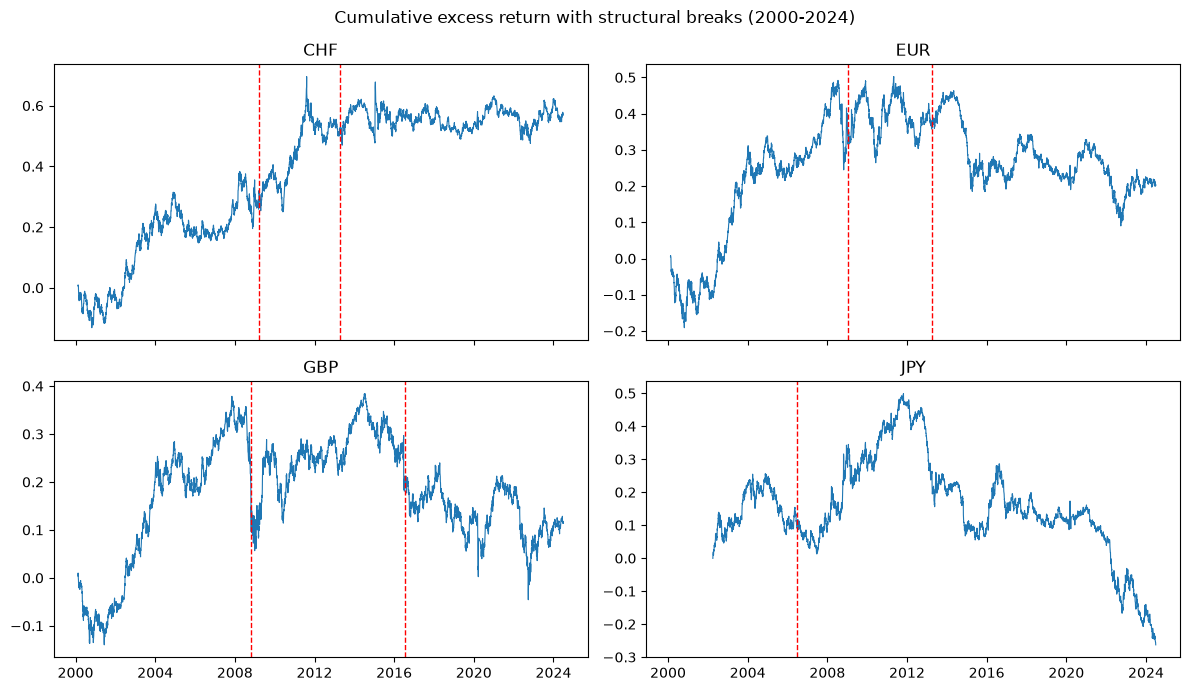

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(12, 7), sharex=True)
for ax, cur in zip(axes.ravel(), CURRENCIES):
    df = frames[cur]
    ax.plot(df.index, df["excess"].cumsum(), lw=0.8)
    for i in breaks[cur][:-1]:
        ax.axvline(df.index[i - 1], color="red", ls="--", lw=1)
    ax.set_title(cur)
fig.suptitle("Cumulative excess return with structural breaks (2000-2024)")
fig.tight_layout()

FIG_DIR.mkdir(exist_ok=True)
fig.savefig(FIG_DIR / "breakpoints.png", dpi=120, bbox_inches="tight")
plt.show()

## Persist

In [12]:
out = DATA_DIR / "break_dates.csv"
break_dates.to_frame().to_csv(out)
print(f"Saved break dates -> {out}")
print(f"Saved figure -> {FIG_DIR / 'breakpoints.png'}")

Saved break dates -> /workspaces/safe-haven-dlm-public/data/break_dates.csv
Saved figure -> /workspaces/safe-haven-dlm-public/figures/breakpoints.png


## Export tables to LaTeX

Write the break dates and the per-currency period regressions to `../paper/` as
`breakdates.tex` and `period_<CUR>.tex`, included by the paper via `\input{}`.

In [13]:
PAPER = PAPER_DIR; PAPER.mkdir(exist_ok=True)

def _star(p):
    return "^{***}" if p < 0.01 else "^{**}" if p < 0.05 else "^{*}" if p < 0.10 else ""

# --- break dates table (unchanged) ---
bd = [r"\begin{table}[H]", r"\centering",
      r"\caption{Estimated Bai-Perron structural-break dates per currency.}",
      r"\label{tab:breaks}", r"\begin{tabular}{ll}", r"\toprule",
      r"Currency & Break dates \\", r"\midrule"]
for cur in CURRENCIES:
    ds = ", ".join(frames[cur].index[i - 1].date().isoformat() for i in breaks[cur][:-1])
    bd.append(f"{cur} & {ds} " + r"\\")
bd += [r"\bottomrule", r"\end{tabular}", r"\end{table}"]
(PAPER / "breakdates.tex").write_text("\n".join(bd))

# --- period regressions: variables in rows, periods in columns, SE in parentheses ---
DISP = {"Intercept": "const", "SP500": "SP500", "UST10Y": "UST10Y",
        "fxvol": "fxvol", "TED": "TED", "VIX": "VIX"}
ORDER = ["Intercept"] + REGRESSORS

for cur in CURRENCIES:
    df = frames[cur]; edges = [0] + breaks[cur]
    results, labels = [], []
    for j in range(len(edges) - 1):
        seg = df.iloc[edges[j]:edges[j + 1]]
        res = smf.ols("excess ~ " + " + ".join(REGRESSORS), data=seg).fit(
            cov_type="HAC", cov_kwds={"maxlags": 2})
        results.append(res)
        labels.append(f"{seg.index[0].year}--{seg.index[-1].year}")
    K = len(results)
    L = [r"\begin{table}[H]", r"\centering", r"\small",
         r"\setlength{\tabcolsep}{5pt}",
         rf"\caption{{{cur}: OLS by structural-break period (Newey-West HAC, lag 2). "
         rf"Standard errors in parentheses; $^{{*}}p<0.1$, $^{{**}}p<0.05$, $^{{***}}p<0.01$.}}",
         rf"\label{{tab:period_{cur}}}",
         r"\begin{tabular}{l" + "r" * K + "}", r"\toprule",
         " & " + " & ".join(f"({i + 1})" for i in range(K)) + r" \\",
         " & " + " & ".join(labels) + r" \\", r"\midrule"]
    for v in ORDER:
        coef = " & ".join(f"${r.params[v]:.3f}{_star(r.pvalues[v])}$" for r in results)
        se = " & ".join(f"$({r.bse[v]:.3f})$" for r in results)
        L.append(f"{DISP[v]} & {coef} " + r"\\")
        L.append(f" & {se} " + r"\\")
    L.append(r"\midrule")
    L.append(r"$N$ & " + " & ".join(str(int(r.nobs)) for r in results) + r" \\")
    L.append(r"$R^2$ & " + " & ".join(f"{r.rsquared:.3f}" for r in results) + r" \\")
    L += [r"\bottomrule", r"\end{tabular}", r"\end{table}"]
    (PAPER / f"period_{cur}.tex").write_text("\n".join(L))
print("Wrote paper/breakdates.tex and transposed period_<CUR>.tex")

Wrote paper/breakdates.tex and transposed period_<CUR>.tex


## Excess returns with breaks (appendix figure)

The daily excess-return series per currency with the estimated break dates
(dashed), the non-cumulative counterpart to the figure above.

## Break-date confidence intervals (local bootstrap)

The exact dynamic program returns point estimates only. Each break's uncertainty
is obtained with a local, break-conditional residual bootstrap (the analogue of
`strucchange::confint`): holding the neighbouring breaks fixed, the residuals of
the two-regime fit in the window spanning the break's adjacent segments are
resampled, a single break is re-located in that window, and the 2.5/97.5
percentiles of its position give the interval. This keeps each interval local to
its point estimate and reflects how sharply that break is identified.

In [14]:
def bootstrap_break_ci(cur, B=200, seed=0):
    df = frames[cur]
    y = df["excess"].values
    X = np.column_stack([np.ones(len(df)), df[REGRESSORS].values])
    bkps = breaks[cur]
    m = len(bkps) - 1
    if m == 0:
        return []
    edges = [0] + list(bkps)
    rng = np.random.default_rng(seed)
    ci = []
    for j in range(m):
        a, b, brk = edges[j], edges[j + 2], edges[j + 1]   # window = two adjacent segments
        Xw, yw = X[a:b], y[a:b]
        Lw, s = b - a, brk - a
        fitw = np.empty(Lw)
        fitw[:s] = Xw[:s] @ np.linalg.lstsq(Xw[:s], yw[:s], rcond=None)[0]
        fitw[s:] = Xw[s:] @ np.linalg.lstsq(Xw[s:], yw[s:], rcond=None)[0]
        resw = yw - fitw
        locs = []
        for _ in range(B):
            y_star = fitw + resw[rng.integers(0, Lw, Lw)]
            g = prefix_gram(y_star, Xw)
            ms = max(5, int(0.1 * Lw))
            t = np.arange(ms, Lw - ms + 1)
            locs.append(a + int(t[np.argmin(seg_rss(g, 0, t) + seg_rss(g, t, Lw))]))
        lo, hi = np.percentile(locs, [2.5, 97.5]).astype(int)
        ci.append((df.index[brk - 1], df.index[lo - 1], df.index[hi - 1]))
    return ci

B_BOOT = 200
break_ci = {cur: bootstrap_break_ci(cur, B=B_BOOT) for cur in CURRENCIES}
for cur in CURRENCIES:
    print(cur)
    for point, lo, hi in break_ci[cur]:
        print(f"  {point.date()}  95% CI [{lo.date()} .. {hi.date()}]")

CHF
  2009-03-24  95% CI [2009-02-25 .. 2009-04-24]
  2013-04-18  95% CI [2012-07-09 .. 2014-05-20]
EUR
  2009-01-07  95% CI [2008-12-05 .. 2009-02-02]
  2013-03-28  95% CI [2012-09-11 .. 2013-08-22]
GBP
  2008-10-20  95% CI [2008-10-03 .. 2008-10-27]
  2016-07-14  95% CI [2015-05-28 .. 2018-11-29]
JPY
  2006-06-29  95% CI [2004-12-23 .. 2007-07-10]


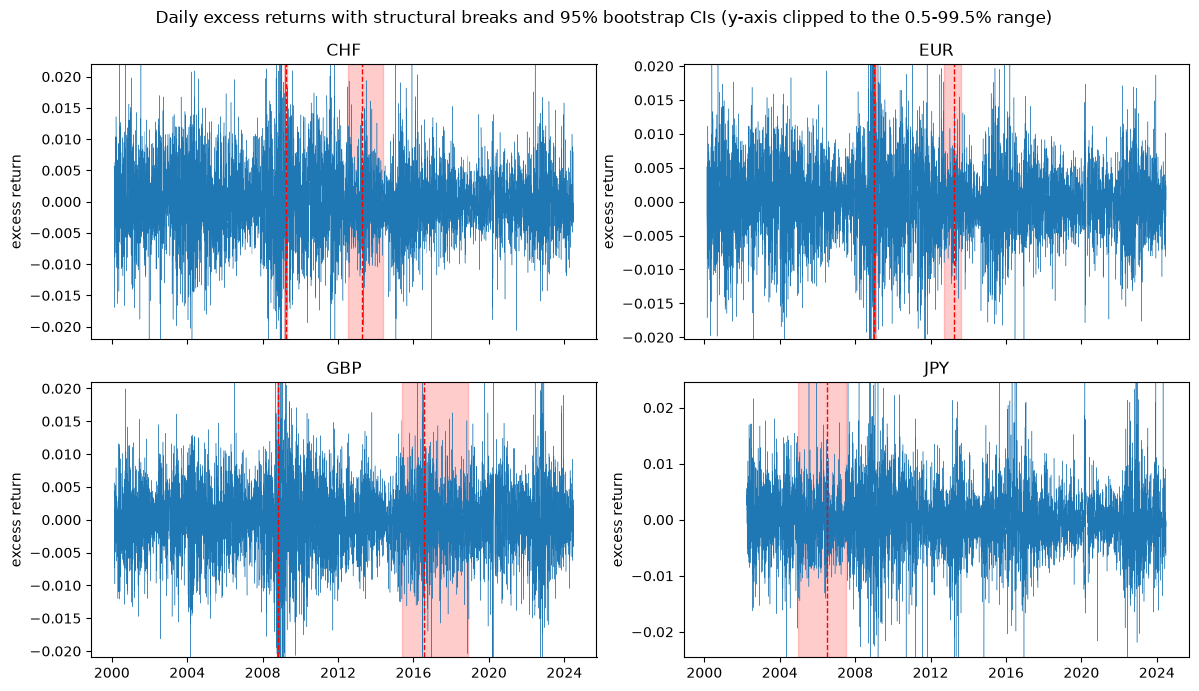

In [15]:
fig, axes = plt.subplots(2, 2, figsize=(12, 7), sharex=True)
for ax, cur in zip(axes.ravel(), CURRENCIES):
    e = frames[cur]["excess"]
    ax.plot(e.index, e, color="C0", lw=0.3)
    for point, lo, hi in break_ci[cur]:
        ax.axvspan(lo, hi, color="red", alpha=0.20)
        ax.axvline(point, color="red", ls="--", lw=1)
    q = max(abs(e.quantile(0.005)), abs(e.quantile(0.995)))   # robust symmetric limits
    ax.set_ylim(-1.15 * q, 1.15 * q)
    ax.set_title(cur); ax.set_ylabel("excess return")
fig.suptitle("Daily excess returns with structural breaks and 95% bootstrap CIs "
             "(y-axis clipped to the 0.5-99.5% range)")
fig.tight_layout()
fig.savefig(FIG_DIR / "excess_returns_breaks.png", dpi=300, bbox_inches="tight")
plt.show()

## Number of breaks: BIC path

The number of breaks per currency is the value of `m` that minimises the BIC.
This plot shows the BIC as a function of `m` with the selected value marked.

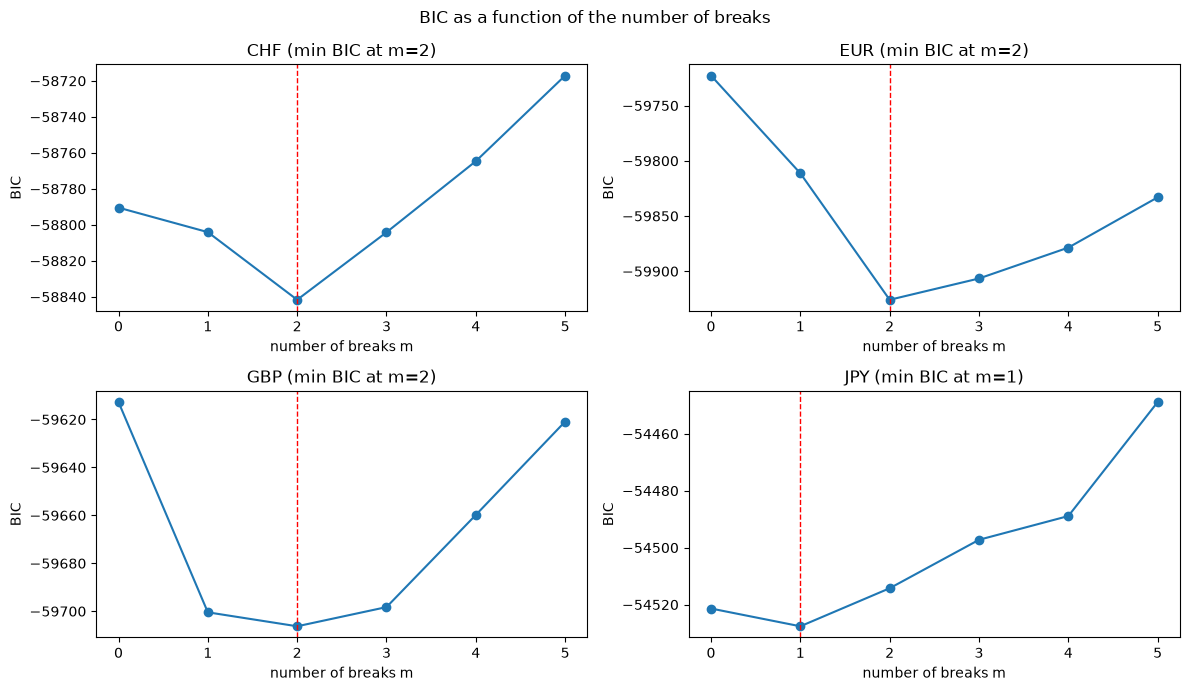

In [16]:
fig, axes = plt.subplots(2, 2, figsize=(12, 7))
for ax, cur in zip(axes.ravel(), CURRENCIES):
    b = fits[cur][1]
    mstar = int(np.argmin(b))
    ax.plot(range(len(b)), b, marker="o")
    ax.axvline(mstar, color="red", ls="--", lw=1)
    ax.set_title(f"{cur} (min BIC at m={mstar})")
    ax.set_xlabel("number of breaks m"); ax.set_ylabel("BIC")
fig.suptitle("BIC as a function of the number of breaks")
fig.tight_layout()
fig.savefig(FIG_DIR / "bic_vs_m.png", dpi=300, bbox_inches="tight")
plt.show()

## Export: break dates with confidence intervals

In [17]:
L = [r"\begin{table}[H]", r"\centering",
     r"\caption{Estimated structural-break dates with 95\% bootstrap confidence "
     r"intervals (residual bootstrap, $B=200$).}",
     r"\label{tab:breakci}", r"\begin{tabular}{llll}", r"\toprule",
     r"Currency & Break date & CI lower & CI upper \\", r"\midrule"]
for cur in CURRENCIES:
    if not break_ci[cur]:
        L.append(f"{cur} & \\multicolumn{{3}}{{c}}{{no break}} " + r"\\"); continue
    for j, (point, lo, hi) in enumerate(break_ci[cur]):
        name = cur if j == 0 else ""
        L.append(f"{name} & {point.date()} & {lo.date()} & {hi.date()} " + r"\\")
    L.append(r"\midrule")
if L[-1] == r"\midrule":
    L = L[:-1]
L += [r"\bottomrule", r"\end{tabular}", r"\end{table}"]
(PAPER_DIR / "breakdates_ci.tex").write_text("\n".join(L))
print("Wrote ../paper/breakdates_ci.tex")

Wrote ../paper/breakdates_ci.tex
